# Exercise 3-1: Create some plots

### Did you use a language model?

### No, I did not use an LLM for code as I followed along the ppt and experimented BUT I used an LLM for writing comments.

#### What did you do to verify that your code worked as expected, whether you used a language model or not?

#### Referred to the PPT for code.

In [3]:
# Import the pandas library and alias it as 'pd' for convenient access to its functionalities.
import pandas as pd

## Get the data

In [4]:
# Load the preprocessed mortality data from a pickle file using pandas
mortality_data = pd.read_pickle('mortality_prepped.pkl')
# Display the first five rows of the loaded mortality data to get a quick overview.
mortality_data.head()

,Year,AgeGroup,DeathRate,MeanCentered
0,1900,01-04 Years,1983.8,1790.87584
1,1901,01-04 Years,1695.0,1502.07584
2,1902,01-04 Years,1655.7,1462.77584
3,1903,01-04 Years,1542.1,1349.17584
4,1904,01-04 Years,1591.5,1398.57584


In [5]:
mortality_wide = pd.read_pickle('mortality_wide.pkl')
# Display the first five rows of the loaded mortality_wide data to get a quick overview.
mortality_wide.head()
# Display the first five rows of the loaded mortality data to get a quick overview.

AgeGroup,01-04 Years,05-09 Years,10-14 Years,15-19 Years
Year,,,,
1900,1983.8,466.1,298.3,484.8
1901,1695.0,427.6,273.6,454.4
1902,1655.7,403.3,252.5,421.5
1903,1542.1,414.7,268.2,434.1
1904,1591.5,425.0,305.2,471.4


## Visualize the data

<Axes: xlabel='Year', ylabel='DeathRate'>

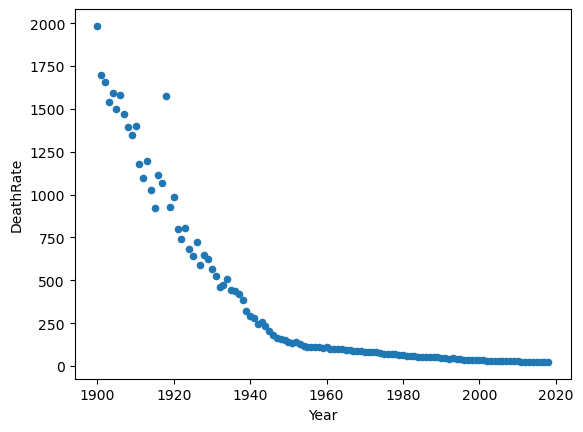

In [6]:
# Filter the mortality_data for entries where the AgeGroup is "01-04 Years", then plot a scatter plot
# with 'Year' on the x-axis and 'DeathRate' on the y-axis to analyze trends over time for this age group.
mortality_data.query('AgeGroup == "01-04 Years"').plot.scatter(x='Year', y='DeathRate')

<Axes: xlabel='Year'>

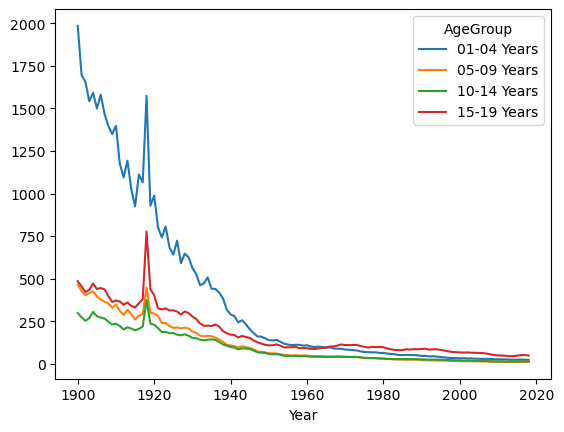

In [14]:
# Plot all columns of the 'mortality_wide' DataFrame against the index using a line plot. This command will
# generate a line plot for each column in the DataFrame, providing a visual comparison of trends across
# different columns over the index values (typically time or another ordered sequence).
mortality_wide.plot()

<Axes: title={'center': 'Child Mortality 15-19 Years'}, xlabel='Year'>

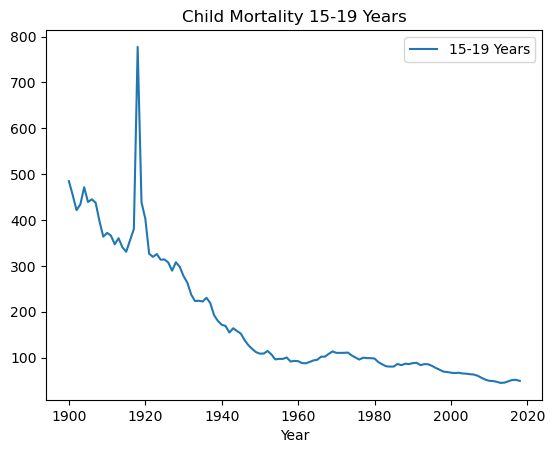

In [15]:
# Plot a line graph for the '15-19 Years' column from the 'mortality_wide' DataFrame. The graph is titled
# 'Child Mortality 15-19 Years' to specifically highlight mortality trends within that age group. The legend
# is disabled (legend='False') for a cleaner visual presentation, focusing solely on the trend line.
mortality_wide.plot.line(y='15-19 Years', title= 'Child Mortality 15-19 Years', legend= 'False')

<Axes: xlabel='Year'>

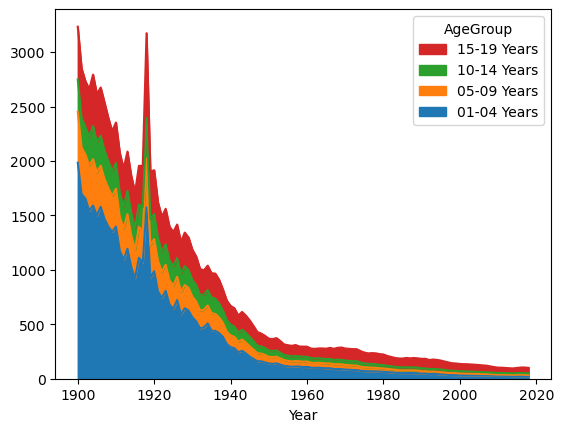

In [16]:
# Generate an area plot for the 'mortality_wide' DataFrame, which will stack the areas representing each
# column on top of one another. The 'legend = 'reverse'' option is used to reverse the order of legend entries,
# ensuring the legend matches the stacking order in the plot for easier interpretation.
mortality_wide.plot.area(legend = 'reverse')

<Axes: title={'center': 'Child Mortality: 2000'}>

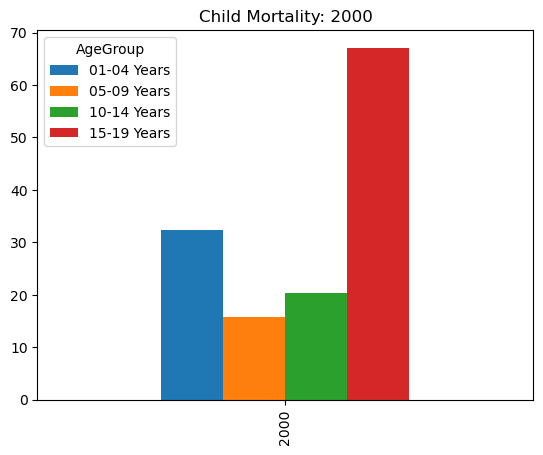

In [19]:
# Filter 'mortality_wide' for the year 2000, then plot a bar chart with the title 'Child Mortality: 2000'.
# The x-axis label is removed for clarity.
mortality_wide.query('Year == 2000')\
.plot.bar(title='Child Mortality: 2000', xlabel = '')

<Axes: title={'center': 'Child Mortality: Year 2000'}, xlabel='AgeGroup'>

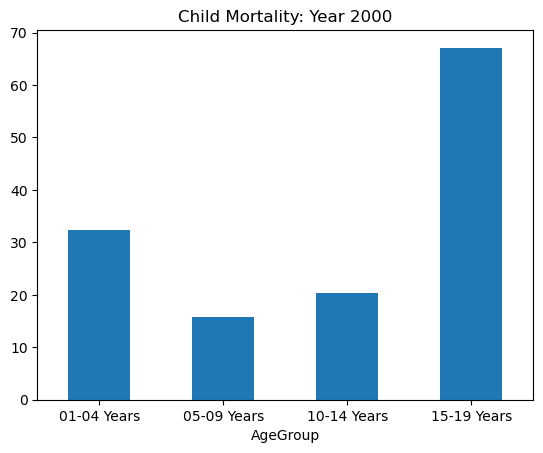

In [27]:
# Filter the dataset for the year 2000, pivot to reorganize data with AgeGroup as rows, Year as columns, 
# and DeathRate as values. Then, plot a bar chart titled 'Child Mortality: Year 2000' without a legend and 
# with horizontal x-axis labels (rot=0) for clear age group identification.
mortality_data.query('Year == 2000') \
    .pivot(index='AgeGroup', columns='Year', values='DeathRate') \
    .plot.bar(title='Child Mortality: Year 2000', legend=False, rot=0)

<Axes: ylabel='Frequency'>

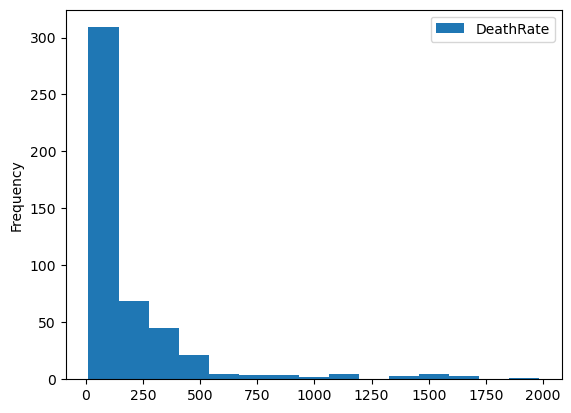

In [44]:
# Plot a histogram of the 'DeathRate' column from 'mortality_data' using 15 bins. This visualizes the 
# distribution of death rates across the dataset, helping identify common ranges and outliers.
mortality_data.plot.hist(y='DeathRate', bins=15)

<Axes: title={'center': 'Child Mortality Density: Year 1900'}, ylabel='Density'>

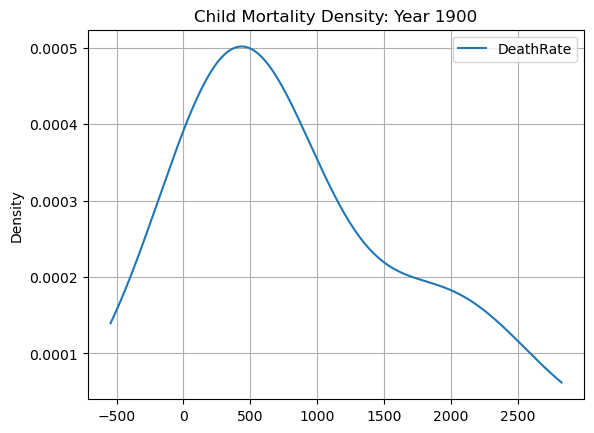

In [31]:
# For the year 1900, this line plots the density (a smoothed, continuous version of a histogram) of the 'DeathRate' 
# from 'mortality_data'. It includes a grid for easier reading and is titled 'Child Mortality Density: Year 1900', 
# helping visualize the distribution and concentration of death rates for that year.
mortality_data.query('Year==1900') \
    .plot.density(y='DeathRate', grid=True, title='Child Mortality Density: Year 1900')

<Axes: ylabel='DeathRate'>

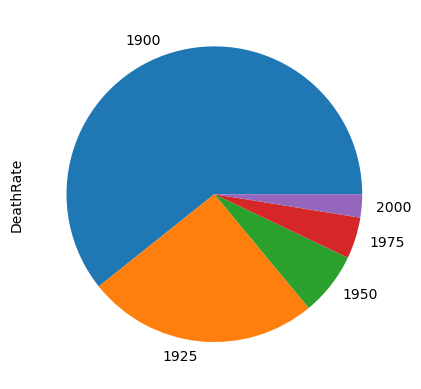

In [32]:
# This code filters 'mortality_data' for the years 1900, 1925, 1950, 1975, and 2000, then groups the data by 'Year'.
# It sums up the 'DeathRate' for each year and plots these sums in a pie chart. This visualization compares the total
# death rates across these selected years, illustrating changes or trends in child mortality over time.
mortality_data.query('Year in (1900, 1925, 1950, 1975, 2000)') \
    .groupby('Year').DeathRate.sum().plot.pie()

array([[<Axes: title={'center': 'Child Mortality: 01-04'}, xlabel='Year'>,
        <Axes: title={'center': 'Child Mortality: 05-09'}, xlabel='Year'>],
       [<Axes: title={'center': 'Child Mortality: 10-14'}, xlabel='Year'>,
        <Axes: title={'center': 'Child Mortality: 15-19'}, xlabel='Year'>]],
      dtype=object)

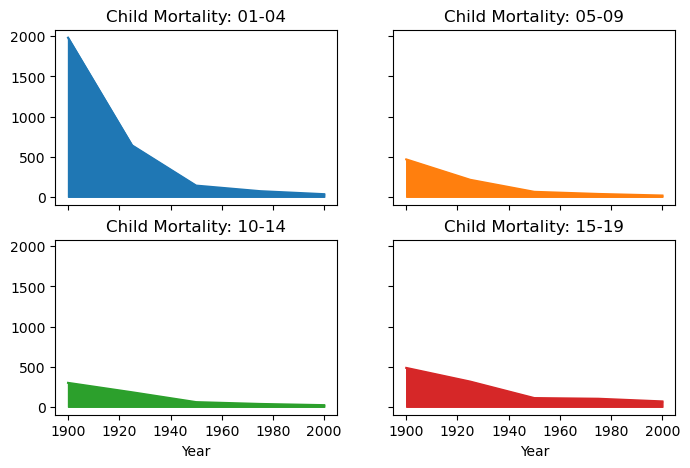

In [55]:
# Filter 'mortality_wide' for specific years (1900, 1925, 1950, 1975, 2000), then create horizontal bar charts 
# for each age group ('01-04', '05-09', '10-14', '15-19') as separate subplots arranged in a 2x2 layout. 
# Each subplot is titled to reflect its respective child mortality age group, sharing the y-axis across subplots 
# for consistent comparison. The 'legend' is set to False to simplify visualization, and 'figsize' is specified 
# to optimize space and readability of the charts.
mortality_wide.query('Year in (1900, 1925, 1950, 1975, 2000)').plot.area(
    title=['Child Mortality: 01-04', 'Child Mortality: 05-09',
           'Child Mortality: 10-14', 'Child Mortality: 15-19'],
    sharey=True, legend=False, subplots=True, layout=(2, 2), figsize=(8,5))